In [2]:
import sys
import os

# 1. Add 'src' to your Python path so we can resolve the 'google.adk.scope' imports
sys.path.insert(0, os.path.abspath("src"))

# 2. (Optional but recommended) Auto-reload modules when you change the .py files
%load_ext autoreload
%autoreload 2

# 3. Import the required files
from google.adk.scope import features_pb2
from google.adk.scope.utils import similarity
from google.protobuf import text_format
import pandas as pd
import numpy as np
import logging

logging.basicConfig(level=logging.DEBUG)

In [3]:
pg = pd.read_csv('./output/py_go.csv').sort_values(by = ['score', 'type'], ascending=False).copy()
pj = pd.read_csv('./output/py_java.csv').sort_values(by = ['score', 'type'], ascending=False).copy()
pt = pd.read_csv('./output/py_ts.csv').sort_values(by = ['score', 'type'], ascending=False).copy()

pg.shape, pj.shape, pt.shape

((1426, 10), (1426, 10), (1426, 10))

In [4]:
pg['score'].describe()

count    1426.000000
mean        0.409128
std         0.152272
min         0.000000
25%         0.349225
50%         0.407950
75%         0.476100
max         0.992100
Name: score, dtype: float64

In [5]:
pj['score'].describe()

count    1426.000000
mean        0.528424
std         0.284260
min         0.000000
25%         0.391550
50%         0.486150
75%         0.797150
max         1.000000
Name: score, dtype: float64

In [6]:
pt['score'].describe()

count    1426.000000
mean        0.532307
std         0.224664
min         0.170800
25%         0.373025
50%         0.452750
75%         0.589400
max         1.000000
Name: score, dtype: float64

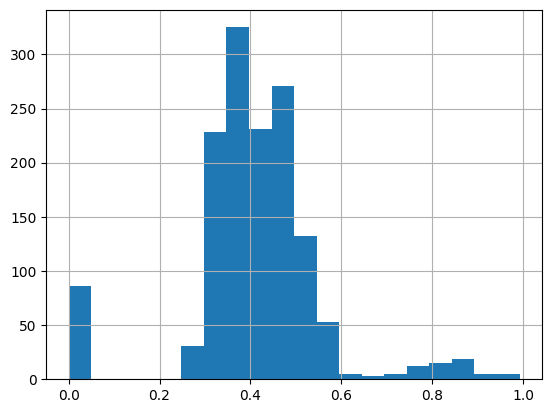

In [14]:
pg['score'].hist(bins=20);

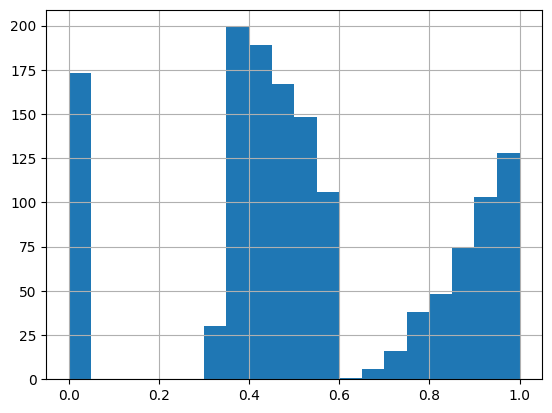

In [8]:
pj['score'].hist(bins=20);

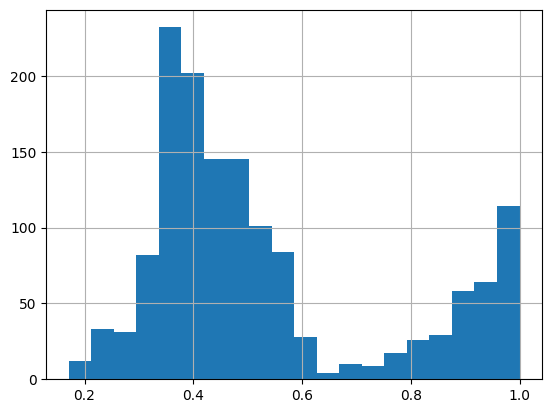

In [9]:
pt['score'].hist(bins=20);

In [10]:
# PYTHON <-> GO:
# 0.6 <= GOOD
# 0.5 < AVERAGE <= 0.6
# BAD <= 0.5 
LOWER, UPPER = 0.4599, 0.4999
print(len(pg[(LOWER < pg['score']) & (pg['score'] < UPPER)]))
pg[(LOWER < pg['score']) & (pg['score'] < UPPER)].head(5)

218


,py_namespace,py_member_of,py_name,go_namespace,go_member_of,go_name,type,score,match,confidence
1399,flows.llm_flows,NaN,merge_parallel_function_response_events,internal.utils,NaN,FunctionResponses,function,0.4991,False,high
263,plugins,BasePlugin,on_model_error_callback,internal.plugininternal,PluginManager,RunOnModelErrorCallback,method,0.4989,False,high
1213,tools.openapi_tool.auth,NaN,dict_to_auth_scheme,internal.typeutil,NaN,ConvertToWithJSONSchema,function,0.4989,False,high
1288,cli.plugins,ReplayPlugin,__init__,plugin,Plugin,New,constructor,0.4989,False,high
219,plugins,HybridContentParser,parse,cmd.launcher.console,ConsoleLauncher,Parse,method,0.4983,False,high


In [11]:
# PYTHON <-> JAVA:
# 0.6 <= GOOD
# BAD <= 0.6
LOWER, UPPER = 0.4999, 0.5999
print(len(pj[(LOWER < pj['score']) & (pj['score'] < UPPER)]))
pj[(LOWER < pj['score']) & (pj['score'] < UPPER)].head(5)

252


,py_namespace,py_member_of,py_name,java_namespace,java_member_of,java_name,type,score,match,confidence
1,runners,Runner,rewind_async,runner,Runner,runAsync,method,0.5978,True,low
1071,tools.computer_use,ComputerUseToolset,close,tools.mcp,McpAsyncToolset,close,method,0.5975,True,low
1153,tools.application_integration_tool.clients,ConnectionsClient,get_entity_schema_and_operations,tools.applicationintegrationtoolset,ConnectionsClient,convertJsonSchemaToOpenApiSchema,method,0.5970,True,low
594,cli,AdkWebServer,get_session_trace,web,AdkWebServer,sessionService,method,0.5962,True,low
1416,flows.llm_flows,BaseLlmFlow,run_async,flows.llmflows,BaseLlmFlow,run,method,0.5959,True,low


In [12]:
# PYTHON <-> TS:
# 0.7 <= GOOD
# 0.55 < AVERAGE <= 0.7
# BAD <= 0.55
LOWER, UPPER = 0.55, 0.7
print(len(pt[(LOWER < pt['score']) & (pt['score'] < UPPER)]))
pt[(LOWER < pt['score']) & (pt['score'] < UPPER)].tail(5)

102


,py_namespace,py_member_of,py_name,ts_namespace,ts_member_of,ts_name,type,score,match,confidence
942,tools.google_api_tool,DocsToolset,__init__,tools.mcp,MCPToolset,constructor,constructor,0.5564,True,low
762,evaluation,NaN,get_all_tool_calls,telemetry,NaN,traceToolCall,function,0.5551,True,low
1280,cli.plugins,RecordingsPlugin,__init__,plugins,LoggingPlugin,constructor,constructor,0.5527,True,low
1006,tools.pubsub,PubSubToolset,__init__,tools,BaseToolset,constructor,constructor,0.5524,True,low
943,tools.google_api_tool,GoogleApiTool,__init__,tools,GoogleSearchTool,constructor,constructor,0.5521,True,low


In [13]:
pg[['match', 'confidence', 'type', 'score']].groupby(['match', 'confidence', 'type']).count()

score
match confidence type              
False high       constructor    377
                 function       206
                 method         604
True  high       constructor     10
                 function         8
                 method          46
      low        constructor     19
                 function        45
                 method         111